In [5]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

In [6]:
F = open('BASE.GK', 'r')
F2 = open('ROVER2.GK', 'r')

t = []
x = []
y = []
z = []

def unp(F):
    t.clear()
    x.clear()
    y.clear()
    z.clear()
    for line in F: 
        data = line.split()
        t.append(float(data[0]))
        x.append(float(data[1]))
        y.append(float(data[2]))
        z.append(float(data[3]))
    a = pd.DataFrame({"t":t,"x":x,"y":y,"z":z})
    return a

b = unp(F)
r2 = unp(F2)
l = 528
r = 1309
b = b[l:r] 
r2 = r2[l:r]
x = r2["x"]
y = r2["y"]
xb = b["x"]
yb = b["y"]

Text(0, 0.5, 'y')

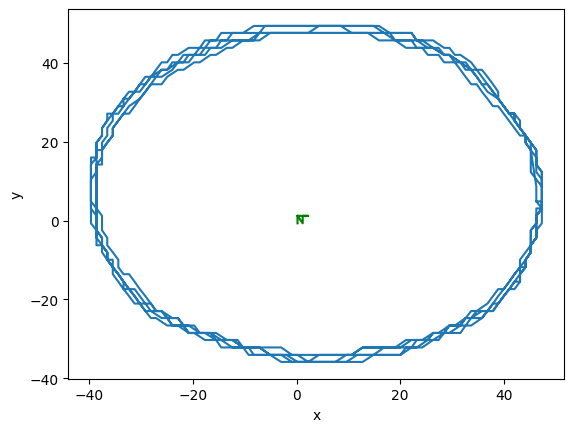

In [7]:
plt.plot(x, y)
plt.plot(xb, yb, color='g')
plt.xlabel("x")
plt.ylabel("y")

Координаты центра: ( 4.329025214331882 , 6.888650201289055 )
Радиус:  42.860416401555746


C:\Users\hp\AppData\Local\Temp\ipykernel_66680\3599895068.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  R = math.sqrt(MNK(A, d))


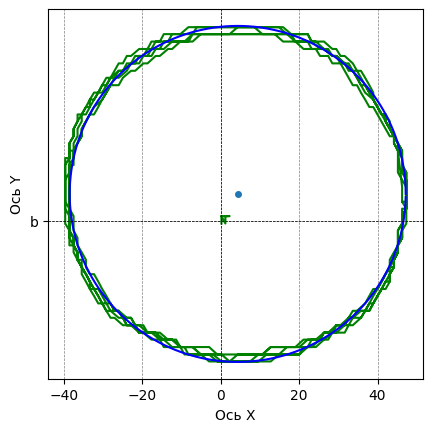

In [8]:
def MNK(x, y):
    beta = (np.linalg.inv(x.T @ x)) @ x.T @ y
    return beta

A = np.zeros([r-l-1, 2])
d = np.zeros(r-l-1)

for i in range(1, r-l):
    A[i-1][0] = 2*(x[i+527]-x[528])
    A[i-1][1] = 2*(y[i+527]-y[528])
    d[i-1] = x[i+527]**2-x[528]**2+y[i+527]**2-y[528]**2

a, b = MNK(A, d)
print("Координаты центра: (",a,",",b,")")

A = np.zeros([r-l, 1]) #строки, столбцы
d = np.zeros(r-l)

for i in range(0, r-l):
    A[i] = 1
    d[i] = (x[i+528] - a)**2 + (y[i+528] - b)**2

R = math.sqrt(MNK(A, d))
print("Радиус: ", R)

x_c = np.zeros(360)
y_c = np.zeros(360)

for i in range(0, 360):
    x_c[i] = a + R*math.cos(i*math.pi/180)
    y_c[i] = b + R*math.sin(i*math.pi/180)

plt.plot(x, y, 'g') # сырой круг
plt.plot(x_c, y_c, 'b')   # чистый круг
plt.plot(xb, yb, 'g')     # сырой центр
plt.plot(a, b, 'o', 'b', markersize=4)
plt.xlabel('Ось X')
plt.ylabel('Ось Y')
plt.gca().set_aspect('equal', adjustable='box')  # Устанавливаем равные масштаб для осей
plt.axhline(0, color='black',linewidth=0.5, ls='--')  # Горизонтальная ось
plt.axvline(0, color='black',linewidth=0.5, ls='--')  # Вертикальная ось
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.5)  # Сетка на графике
plt.show()